# 01 — Data Audit du dataset Tetouan

## Projet : Smart City Energy Forecasting — Tetouan

**Objectif :** Charger le dataset brut *Power Consumption of Tetouan City*, vérifier sa structure, contrôler la qualité des données, produire un premier aperçu visuel et préparer les variables cibles.

**Correspondance méthodologique :** Ce notebook couvre les étapes **7 (Présentation du dataset)** et **8.1–8.2 (Sélection et Exploration initiale des données)** de la méthodologie KDD.

---

### Étapes de ce notebook

1. Chargement et préparation initiale via `src.data_loader`
2. Audit global : dimensions, période, fréquence, valeurs manquantes, doublons
3. Audit par colonne : types, statistiques descriptives
4. Vérification de la régularité temporelle
5. Visualisations d'audit : séries temporelles, distributions, boxplots
6. Sauvegarde du dataset audité

## 1. Importation des bibliothèques

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Style des graphiques
plt.rcParams.update({
    "figure.figsize": (14, 5),
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
sns.set_style("whitegrid")

# Résolution du chemin projet et import du module data_loader
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import (
    load_tetouan_data,
    audit_tetouan_data,
    dataset_quality_summary,
    COLUMN_MAPPING,
    NUMERIC_COLUMNS,
)

print(" Bibliothèques importées avec succès.")
print(f" Racine du projet : {PROJECT_ROOT}")

 Bibliothèques importées avec succès.
 Racine du projet : C:\Users\jarro\OneDrive\Desktop\smart-city-energy-forecasting-tetouan


## 2. Chargement et préparation du dataset

Le chargement est entièrement géré par `src.data_loader.load_tetouan_data()` qui réalise :

1. Lecture du CSV brut
2. Normalisation des espaces multiples dans les noms de colonnes (ex : `Zone 2  Power Consumption` → `Zone 2 Power Consumption`)
3. Vérification des colonnes attendues
4. Renommage technique (cf. tableau ci-dessous)
5. Conversion de la date au format `datetime`
6. Conversion numérique avec détection d'erreurs
7. Tri chronologique
8. Suppression des doublons temporels
9. Création de `target = zone1_power` et `total_load = zone1_power + zone2_power + zone3_power`
10. Indexation temporelle

### Renommage des colonnes

| Colonne originale | Nom technique |
|---|---|
| `DateTime` | `datetime` |
| `Temperature` | `temperature` |
| `Humidity` | `humidity` |
| `Wind Speed` | `wind_speed` |
| `general diffuse flows` | `general_diffuse_flows` |
| `diffuse flows` | `diffuse_flows` |
| `Zone 1 Power Consumption` | `zone1_power` |
| `Zone 2 Power Consumption` | `zone2_power` |
| `Zone 3 Power Consumption` | `zone3_power` |

In [4]:
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Tetuan City power consumption.csv"

df = load_tetouan_data(
    DATA_PATH,
    set_datetime_index=True,
    strict_frequency=True,
)

print(f" Dataset chargé avec succès.")
print(f"   Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"   Index : {df.index.name} ({df.index.dtype})")
print(f"   Colonnes : {list(df.columns)}")

 Dataset chargé avec succès.
   Dimensions : 52,416 lignes × 10 colonnes
   Index : datetime (datetime64[ns])
   Colonnes : ['temperature', 'humidity', 'wind_speed', 'general_diffuse_flows', 'diffuse_flows', 'zone1_power', 'zone2_power', 'zone3_power', 'target', 'total_load']


### Aperçu des premières et dernières lignes

In [5]:
print("═" * 60)
print("PREMIÈRES LIGNES DU DATASET")
print("═" * 60)
display(df.head())

print("\n" + "═" * 60)
print("DERNIÈRES LIGNES DU DATASET")
print("═" * 60)
display(df.tail())

════════════════════════════════════════════════════════════
PREMIÈRES LIGNES DU DATASET
════════════════════════════════════════════════════════════


,temperature,humidity,wind_speed,general_diffuse_flows,diffuse_flows,zone1_power,zone2_power,zone3_power,target,total_load
datetime,,,,,,,,,,
2017-01-01 00:00:00,6.56,73.80,0.08,0.05,0.12,34055.70,16128.88,20240.96,34055.70,70425.54
2017-01-01 00:10:00,6.41,74.50,0.08,0.07,0.09,29814.68,19375.08,20131.08,29814.68,69320.84
2017-01-01 00:20:00,6.31,74.50,0.08,0.06,0.10,29128.10,19006.69,19668.43,29128.10,67803.22
2017-01-01 00:30:00,6.12,75.00,0.08,0.09,0.10,28228.86,18361.09,18899.28,28228.86,65489.23
2017-01-01 00:40:00,5.92,75.70,0.08,0.05,0.09,27335.70,17872.34,18442.41,27335.70,63650.45



════════════════════════════════════════════════════════════
DERNIÈRES LIGNES DU DATASET
════════════════════════════════════════════════════════════


,temperature,humidity,wind_speed,general_diffuse_flows,diffuse_flows,zone1_power,zone2_power,zone3_power,target,total_load
datetime,,,,,,,,,,
2017-12-30 23:10:00,7.01,72.40,0.08,0.04,0.10,31160.46,26857.32,14780.31,31160.46,72798.09
2017-12-30 23:20:00,6.95,72.60,0.08,0.05,0.09,30430.42,26124.58,14428.81,30430.42,70983.81
2017-12-30 23:30:00,6.90,72.80,0.09,0.08,0.07,29590.87,25277.69,13806.48,29590.87,68675.05
2017-12-30 23:40:00,6.76,73.00,0.08,0.07,0.09,28958.17,24692.24,13512.61,28958.17,67163.02
2017-12-30 23:50:00,6.58,74.10,0.08,0.06,0.11,28349.81,24055.23,13345.50,28349.81,65750.54


## 3. Audit global du dataset

Le résumé global vérifie les indicateurs principaux de qualité : dimensions, période couverte, fréquence temporelle, valeurs manquantes et doublons.

In [6]:
quality = dataset_quality_summary(df)

print("═" * 60)
print("AUDIT GLOBAL DU DATASET")
print("═" * 60)
print(f"  Nombre d'observations     : {quality['n_rows']:,}")
print(f"  Nombre de colonnes        : {quality['n_columns']}")
print(f"  Début de période          : {quality['start_date']}")
print(f"  Fin de période            : {quality['end_date']}")
print(f"  Fréquence inférée         : {quality['inferred_frequency']}")
print(f"  Valeurs manquantes totales: {quality['missing_total']}")
print(f"  Doublons temporels        : {quality['duplicated_datetime']}")
print("═" * 60)

# Résumé sous forme de tableau
audit_summary = pd.DataFrame([
    ["Nombre d'observations", f"{quality['n_rows']:,}"],
    ["Nombre de colonnes (après target + total_load)", quality['n_columns']],
    ["Nombre de colonnes dans le fichier brut", 9],
    ["Début de période", quality['start_date']],
    ["Fin de période", quality['end_date']],
    ["Fréquence inférée", quality['inferred_frequency']],
    ["Valeurs manquantes détectées", quality['missing_total']],
    ["Doublons temporels détectés", quality['duplicated_datetime']],
], columns=["Élément", "Valeur observée"])

display(audit_summary.style.hide(axis='index').set_caption("Résumé de l'audit global"))

════════════════════════════════════════════════════════════
AUDIT GLOBAL DU DATASET
════════════════════════════════════════════════════════════
  Nombre d'observations     : 52,416
  Nombre de colonnes        : 10
  Début de période          : 2017-01-01 00:00:00
  Fin de période            : 2017-12-30 23:50:00
  Fréquence inférée         : 10min
  Valeurs manquantes totales: 0
  Doublons temporels        : 0
════════════════════════════════════════════════════════════


Élément,Valeur observée
Nombre d'observations,"52,416"
Nombre de colonnes (après target + total_load),10
Nombre de colonnes dans le fichier brut,9
Début de période,2017-01-01 00:00:00
Fin de période,2017-12-30 23:50:00
Fréquence inférée,10min
Valeurs manquantes détectées,0
Doublons temporels détectés,0


## 4. Audit par colonne — Types, valeurs manquantes et statistiques

Le tableau ci-dessous détaille, pour chaque colonne :
- le type de données
- le nombre et taux de valeurs manquantes
- les statistiques descriptives (min, moyenne, médiane, max, écart-type)

In [7]:
audit_df = audit_tetouan_data(df)
display(audit_df.style.set_caption("Audit qualité par colonne"))

,dtype,missing_count,missing_rate_pct,min,mean,50%,max,std
temperature,float64,0,0.000000,3.247000,18.810024,18.780000,40.010000,5.815476
humidity,float64,0,0.000000,11.340000,68.259518,69.860000,94.800000,15.551177
wind_speed,float64,0,0.000000,0.050000,1.959489,0.086000,6.483000,2.348862
general_diffuse_flows,float64,0,0.000000,0.004000,182.696614,5.035500,1163.000000,264.400960
diffuse_flows,float64,0,0.000000,0.011000,75.028022,4.456000,936.000000,124.210949
zone1_power,float64,0,0.000000,13895.696200,32344.970564,32265.920340,52204.395120,7130.562564
zone2_power,float64,0,0.000000,8560.081466,21042.509082,20823.168405,37408.860760,5201.465892
zone3_power,float64,0,0.000000,5935.174070,17835.406218,16415.117470,47598.326360,6622.165099
target,float64,0,0.000000,13895.696200,32344.970564,32265.920340,52204.395120,7130.562564
total_load,float64,0,0.000000,36785.039739,71222.885864,69788.790940,134208.145950,17143.138964


In [8]:
# Info complète sur les types
print("═" * 60)
print("TYPES DES COLONNES")
print("═" * 60)
df.info()

════════════════════════════════════════════════════════════
TYPES DES COLONNES
════════════════════════════════════════════════════════════
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52416 entries, 2017-01-01 00:00:00 to 2017-12-30 23:50:00
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   temperature            52416 non-null  float64
 1   humidity               52416 non-null  float64
 2   wind_speed             52416 non-null  float64
 3   general_diffuse_flows  52416 non-null  float64
 4   diffuse_flows          52416 non-null  float64
 5   zone1_power            52416 non-null  float64
 6   zone2_power            52416 non-null  float64
 7   zone3_power            52416 non-null  float64
 8   target                 52416 non-null  float64
 9   total_load             52416 non-null  float64
dtypes: float64(10)
memory usage: 6.4 MB


### Interprétation

- **Zéro valeur manquante** sur les 52 416 observations : le dataset est complet.
- **Zéro doublon temporel** : chaque instant est unique.
- Toutes les colonnes numériques sont de type `float64`, ce qui est correct.
- `target` est identique à `zone1_power` (copie de la cible principale).
- `total_load` est la somme des trois zones.

## 5. Statistiques descriptives détaillées

In [9]:
desc = df.describe().T
desc["IQR"] = desc["75%"] - desc["25%"]
desc["CV_%"] = (desc["std"] / desc["mean"] * 100).round(2)

display(desc.style.set_caption("Statistiques descriptives détaillées (avec IQR et CV%)"))

,count,mean,std,min,25%,50%,75%,max,IQR,CV_%
temperature,52416.000000,18.810024,5.815476,3.247000,14.410000,18.780000,22.890000,40.010000,8.480000,30.920000
humidity,52416.000000,68.259518,15.551177,11.340000,58.310000,69.860000,81.400000,94.800000,23.090000,22.780000
wind_speed,52416.000000,1.959489,2.348862,0.050000,0.078000,0.086000,4.915000,6.483000,4.837000,119.870000
general_diffuse_flows,52416.000000,182.696614,264.400960,0.004000,0.062000,5.035500,319.600000,1163.000000,319.538000,144.720000
diffuse_flows,52416.000000,75.028022,124.210949,0.011000,0.122000,4.456000,101.000000,936.000000,100.878000,165.550000
zone1_power,52416.000000,32344.970564,7130.562564,13895.696200,26310.668692,32265.920340,37309.018185,52204.395120,10998.349493,22.050000
zone2_power,52416.000000,21042.509082,5201.465892,8560.081466,16980.766032,20823.168405,24713.717520,37408.860760,7732.951487,24.720000
zone3_power,52416.000000,17835.406218,6622.165099,5935.174070,13129.326630,16415.117470,21624.100420,47598.326360,8494.773790,37.130000
target,52416.000000,32344.970564,7130.562564,13895.696200,26310.668692,32265.920340,37309.018185,52204.395120,10998.349493,22.050000
total_load,52416.000000,71222.885864,17143.138964,36785.039739,56499.074640,69788.790940,83749.172310,134208.145950,27250.097670,24.070000


### Interprétation des statistiques

- **Temperature** : varie de 3.2°C à 40.0°C → climat méditerranéen typique de Tétouan.
- **Humidity** : varie de 11.3% à 94.8%, médiane ~70% → humidité élevée en général.
- **Wind Speed** : médiane très basse (0.09 m/s) mais max à 6.5 → distribution très asymétrique.
- **Flux diffus** (general & diffuse) : médianes proches de zéro → valeurs nocturnes à 0, forts pics diurnes.
- **Zone 1** : consommation moyenne ~32 345 kW, la plus élevée des trois zones.
- **Zone 2** : consommation moyenne ~21 043 kW.
- **Zone 3** : consommation moyenne ~17 835 kW, mais le max (~47 598) est très élevé → forte volatilité.
- Le **CV% (coefficient de variation)** de `zone3_power` est le plus élevé, indiquant la zone la plus volatile.

## 6. Vérification de la régularité temporelle

Un pas régulier de 10 minutes est attendu. Toute discontinuité (gap) pourrait poser problème pour le resampling et les modèles temporels.

In [ ]:
# Calcul des différences entre timestamps consécutifs
time_diffs = df.index.to_series().diff().dropna()
expected_freq = pd.Timedelta("10min")

print("═" * 60)
print("VÉRIFICATION DE LA RÉGULARITÉ TEMPORELLE")
print("═" * 60)
print(f"  Pas attendu               : {expected_freq}")
print(f"  Pas minimum observé       : {time_diffs.min()}")
print(f"  Pas maximum observé       : {time_diffs.max()}")
print(f"  Pas médian observé        : {time_diffs.median()}")
print(f"  Nombre de pas différents  : {time_diffs.nunique()}")

# Nombre de gaps (pas != 10 min)
gaps = time_diffs[time_diffs != expected_freq]
print(f"  Nombre de gaps détectés   : {len(gaps)}")

if len(gaps) > 0:
    print(f"\n   Gaps trouvés :")
    display(gaps.value_counts().head(10))
else:
    print("\n   Aucun gap détecté — le pas est parfaitement régulier à 10 minutes.")

════════════════════════════════════════════════════════════
VÉRIFICATION DE LA RÉGULARITÉ TEMPORELLE
════════════════════════════════════════════════════════════
  Pas attendu               : 0 days 00:10:00
  Pas minimum observé       : 0 days 00:10:00
  Pas maximum observé       : 0 days 00:10:00
  Pas médian observé        : 0 days 00:10:00
  Nombre de pas différents  : 1
  Nombre de gaps détectés   : 0

  ✅ Aucun gap détecté — le pas est parfaitement régulier à 10 minutes.


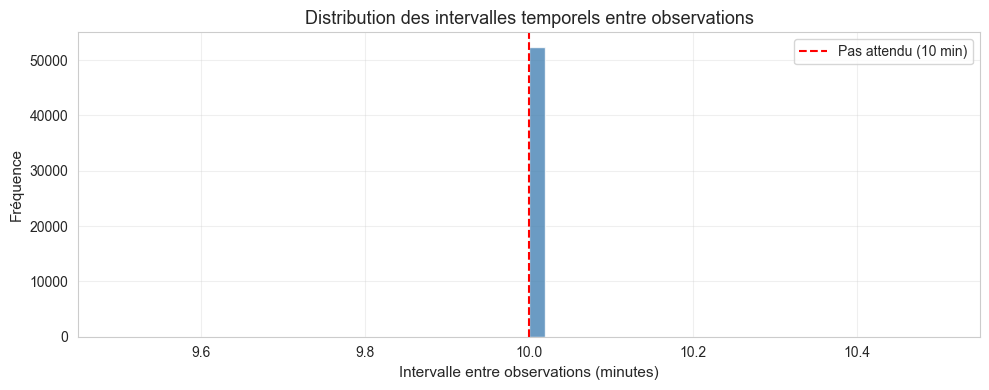

📊 Figure sauvegardée : results/figures/01_temporal_regularity.png


In [11]:
# Visualisation de la distribution des pas temporels
fig, ax = plt.subplots(figsize=(10, 4))
time_diffs_minutes = time_diffs.dt.total_seconds() / 60
ax.hist(time_diffs_minutes, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(x=10, color="red", linestyle="--", linewidth=1.5, label="Pas attendu (10 min)")
ax.set_xlabel("Intervalle entre observations (minutes)")
ax.set_ylabel("Fréquence")
ax.set_title("Distribution des intervalles temporels entre observations")
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "figures" / "01_temporal_regularity.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Figure sauvegardée : results/figures/01_temporal_regularity.png")

## 7. Aperçu visuel des séries temporelles

Visualisation de l'évolution temporelle des trois zones de consommation sur toute l'année 2017. Cet aperçu permet de :
- détecter visuellement les tendances et saisonnalités ;
- repérer d'éventuelles anomalies grossières ;
- comparer les niveaux de consommation entre zones.

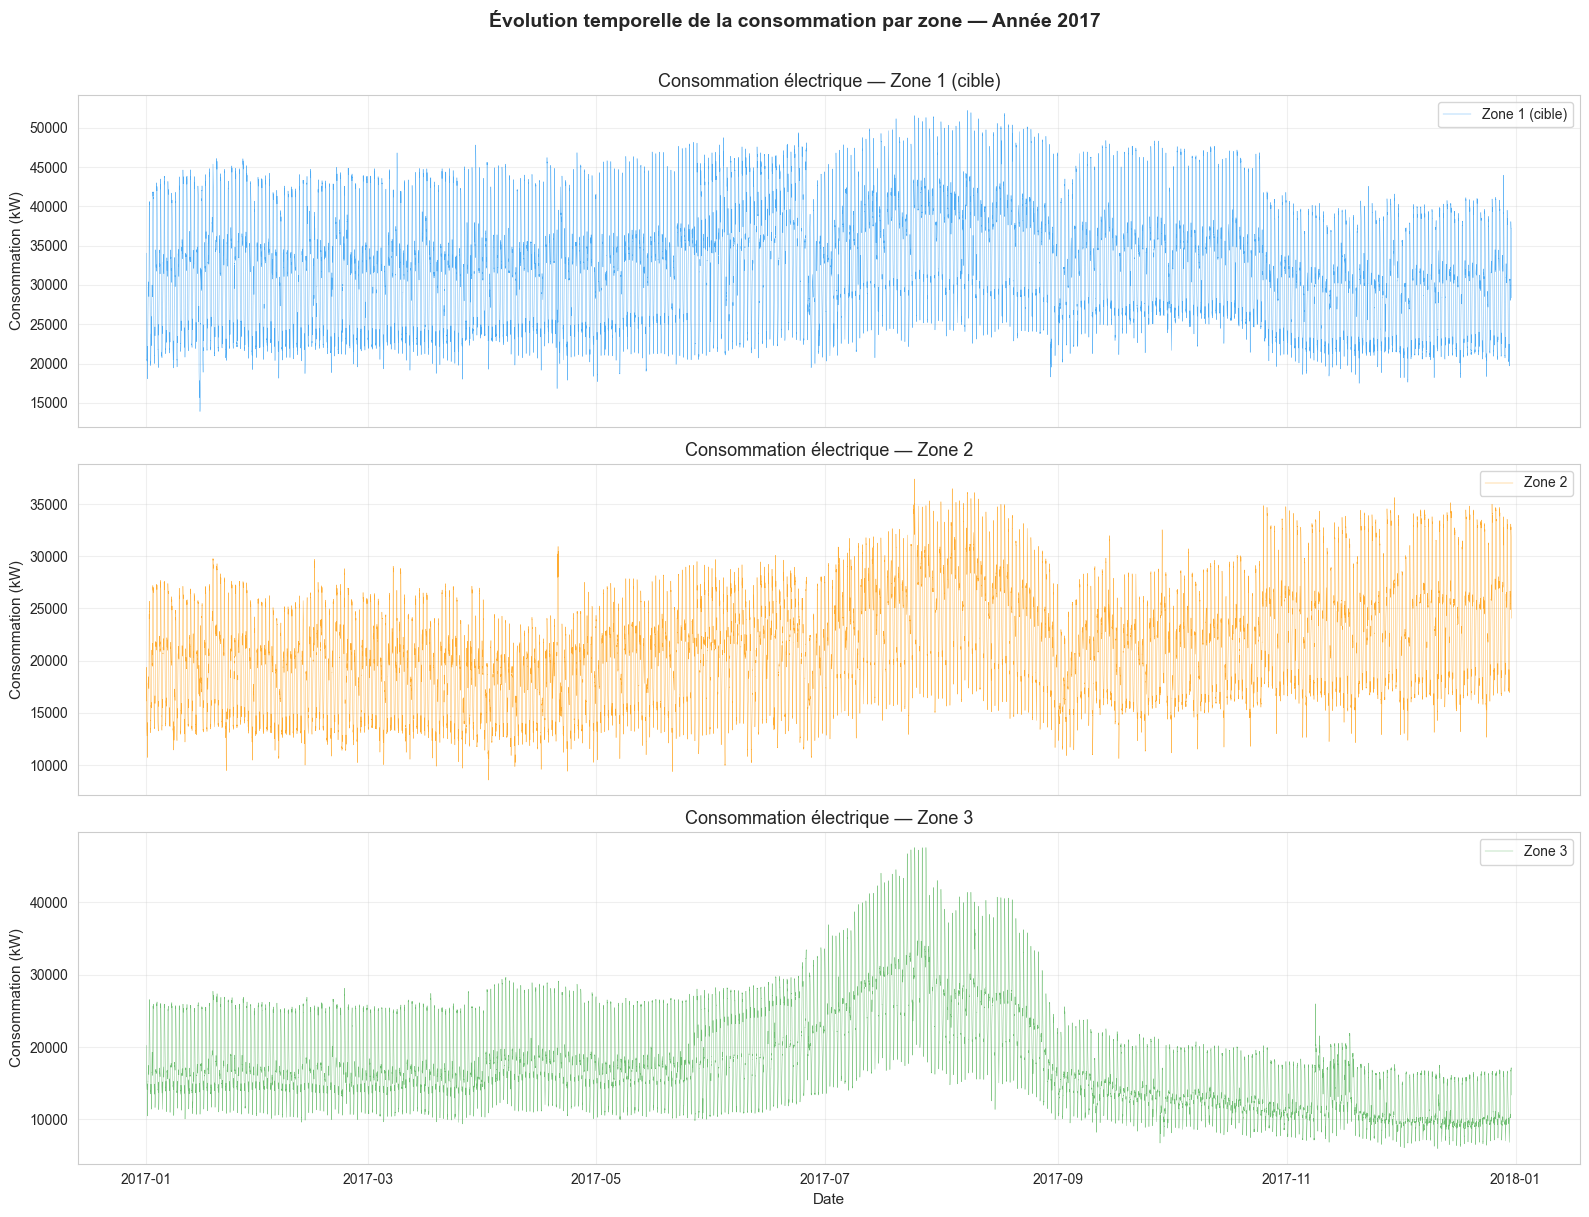

📊 Figure sauvegardée : results/figures/01_series_temporelles_3zones.png


In [12]:
zone_cols = ["zone1_power", "zone2_power", "zone3_power"]
zone_labels = ["Zone 1 (cible)", "Zone 2", "Zone 3"]
zone_colors = ["#2196F3", "#FF9800", "#4CAF50"]

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for ax, col, label, color in zip(axes, zone_cols, zone_labels, zone_colors):
    ax.plot(df.index, df[col], color=color, linewidth=0.3, alpha=0.8)
    ax.set_ylabel("Consommation (kW)")
    ax.set_title(f"Consommation électrique — {label}")
    ax.legend([label], loc="upper right")

axes[-1].set_xlabel("Date")
plt.suptitle("Évolution temporelle de la consommation par zone — Année 2017", 
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "figures" / "01_series_temporelles_3zones.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Figure sauvegardée : results/figures/01_series_temporelles_3zones.png")

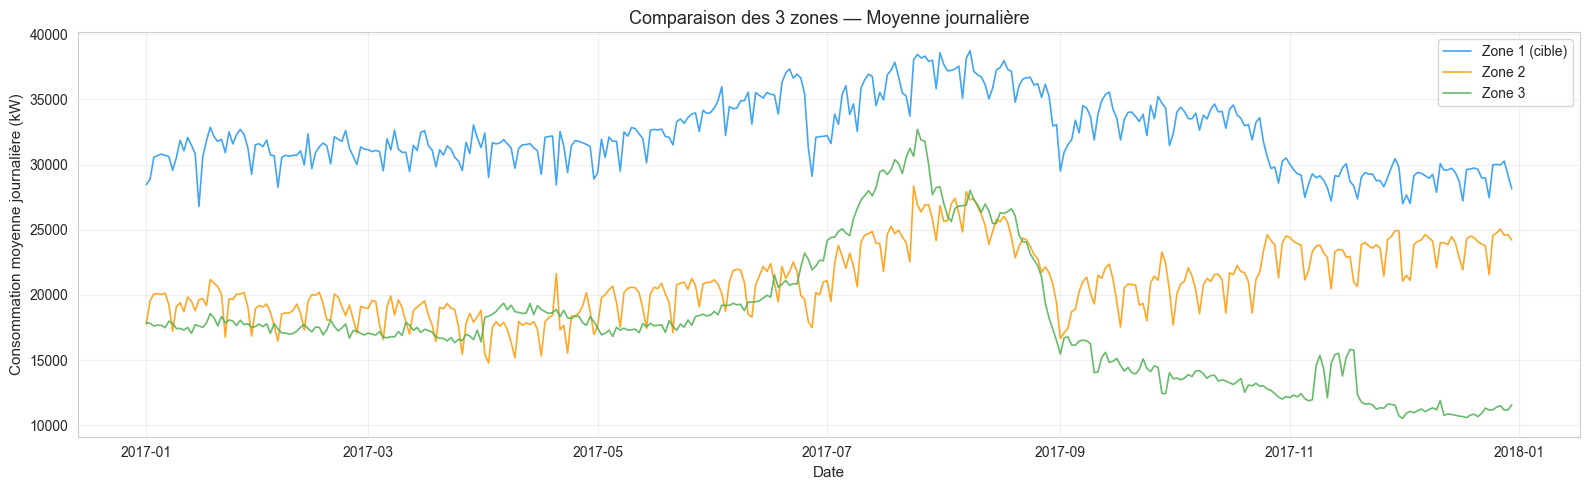

📊 Figure sauvegardée : results/figures/01_comparaison_zones_journalier.png


In [13]:
# Superposition des trois zones sur un même graphique
fig, ax = plt.subplots(figsize=(16, 5))

for col, label, color in zip(zone_cols, zone_labels, zone_colors):
    # Resample journalier pour lisibilité
    daily = df[col].resample("D").mean()
    ax.plot(daily.index, daily.values, color=color, linewidth=1.2, label=label, alpha=0.85)

ax.set_xlabel("Date")
ax.set_ylabel("Consommation moyenne journalière (kW)")
ax.set_title("Comparaison des 3 zones — Moyenne journalière")
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "figures" / "01_comparaison_zones_journalier.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Figure sauvegardée : results/figures/01_comparaison_zones_journalier.png")

## 8. Distribution des variables

Les histogrammes et courbes de densité permettent de comprendre la forme de chaque distribution (symétrie, asymétrie, pics).

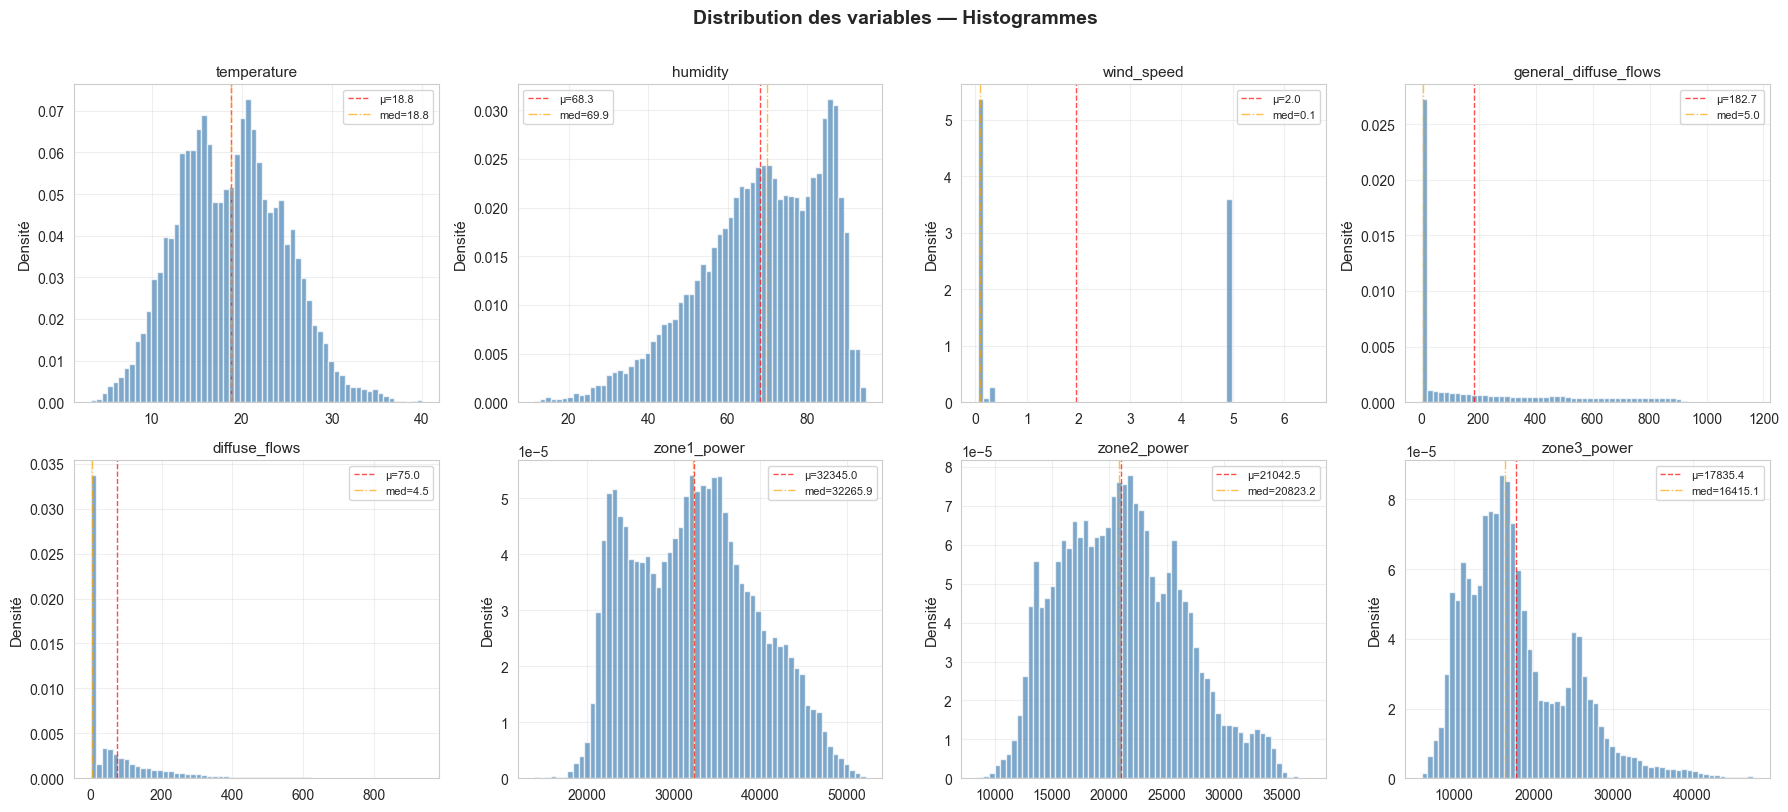

📊 Figure sauvegardée : results/figures/01_distributions_histogrammes.png


In [14]:
# Histogrammes de toutes les variables numériques (hors target et total_load qui sont dérivées)
plot_cols = ["temperature", "humidity", "wind_speed", 
             "general_diffuse_flows", "diffuse_flows",
             "zone1_power", "zone2_power", "zone3_power"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for i, col in enumerate(plot_cols):
    ax = axes[i]
    ax.hist(df[col], bins=60, color="steelblue", edgecolor="white", alpha=0.7, density=True)
    ax.set_title(col, fontsize=11)
    ax.set_ylabel("Densité")
    # Ligne de la moyenne
    ax.axvline(df[col].mean(), color="red", linestyle="--", linewidth=1, alpha=0.7, label=f"μ={df[col].mean():.1f}")
    ax.axvline(df[col].median(), color="orange", linestyle="-.", linewidth=1, alpha=0.7, label=f"med={df[col].median():.1f}")
    ax.legend(fontsize=8)

plt.suptitle("Distribution des variables — Histogrammes", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "figures" / "01_distributions_histogrammes.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Figure sauvegardée : results/figures/01_distributions_histogrammes.png")

## 9. Boxplots — Détection visuelle des valeurs extrêmes

Les boxplots permettent de repérer les outliers potentiels dans chaque variable. Les points au-delà des moustaches (1.5 × IQR) sont des candidats à l'analyse.

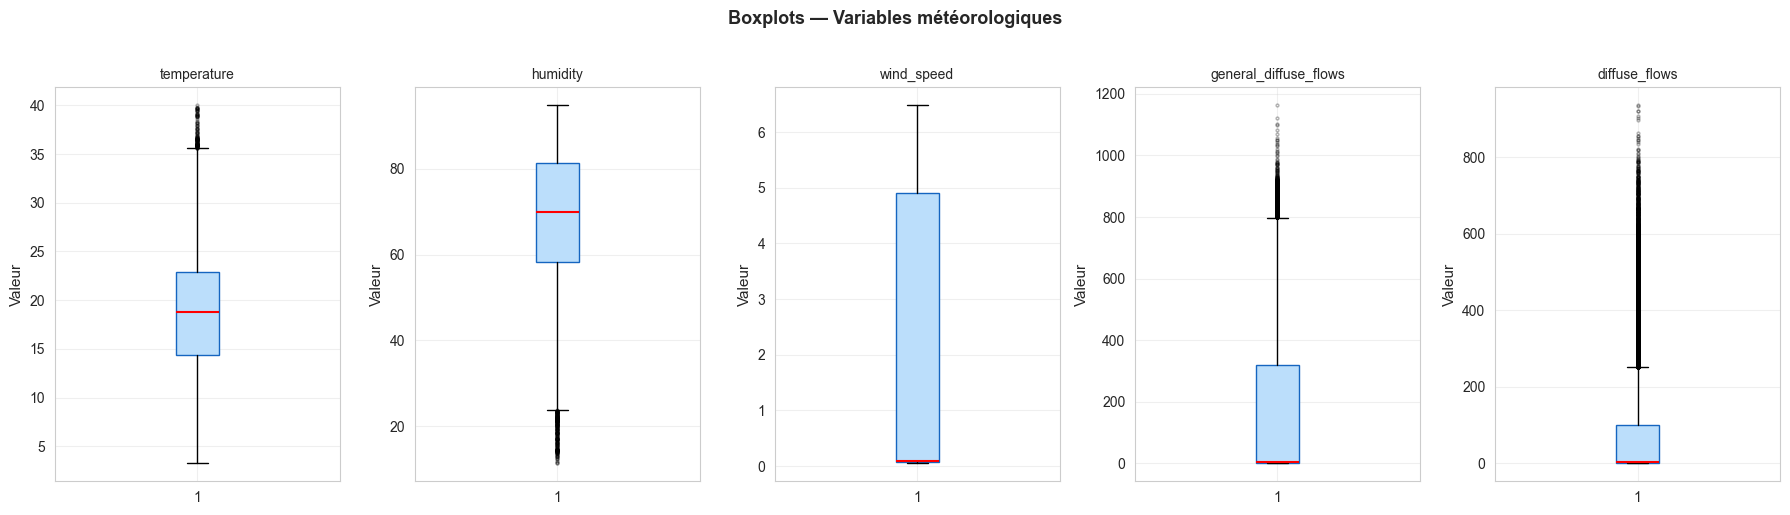

📊 Figure sauvegardée : results/figures/01_boxplots_meteo.png


In [15]:
# Boxplots des variables météo
meteo_cols = ["temperature", "humidity", "wind_speed", "general_diffuse_flows", "diffuse_flows"]

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, col in zip(axes, meteo_cols):
    bp = ax.boxplot(df[col].dropna(), patch_artist=True, 
                    boxprops=dict(facecolor="#bbdefb", edgecolor="#1565c0"),
                    medianprops=dict(color="red", linewidth=1.5),
                    flierprops=dict(marker="o", markersize=2, alpha=0.3))
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("Valeur")

plt.suptitle("Boxplots — Variables météorologiques", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "figures" / "01_boxplots_meteo.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Figure sauvegardée : results/figures/01_boxplots_meteo.png")

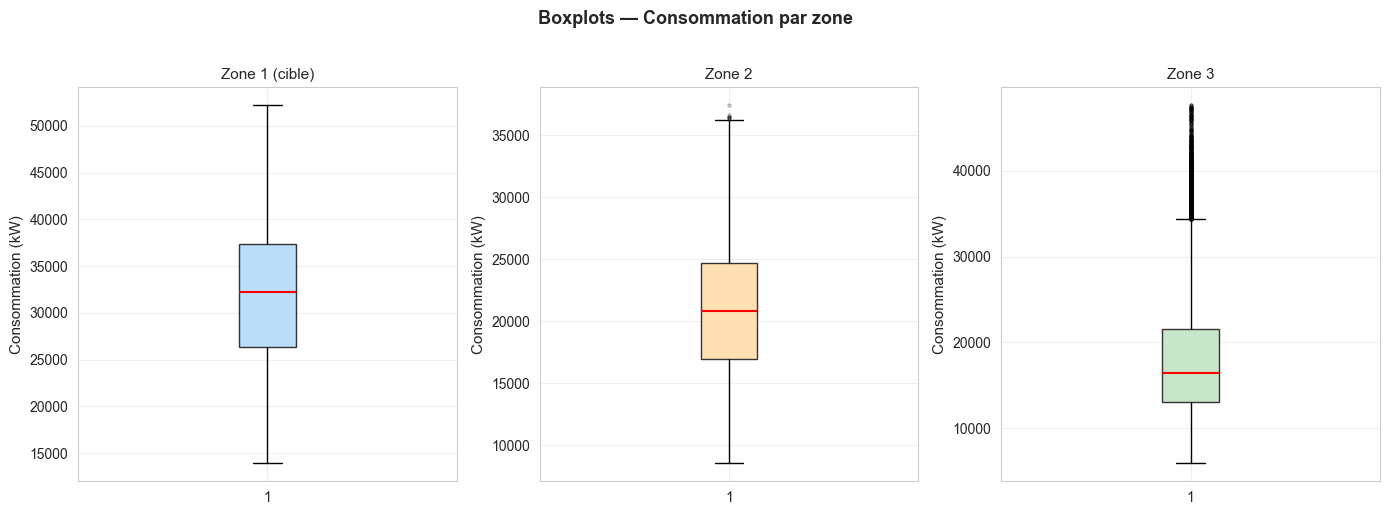

📊 Figure sauvegardée : results/figures/01_boxplots_zones.png


In [16]:
# Boxplots des zones de consommation
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col, label, color in zip(axes, zone_cols, zone_labels, 
                                  ["#bbdefb", "#ffe0b2", "#c8e6c9"]):
    bp = ax.boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=color, edgecolor="#333"),
                    medianprops=dict(color="red", linewidth=1.5),
                    flierprops=dict(marker="o", markersize=2, alpha=0.3))
    ax.set_title(label, fontsize=11)
    ax.set_ylabel("Consommation (kW)")

plt.suptitle("Boxplots — Consommation par zone", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "figures" / "01_boxplots_zones.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Figure sauvegardée : results/figures/01_boxplots_zones.png")

## 10. Matrice de corrélation initiale

Un premier aperçu des corrélations linéaires entre les variables du dataset.

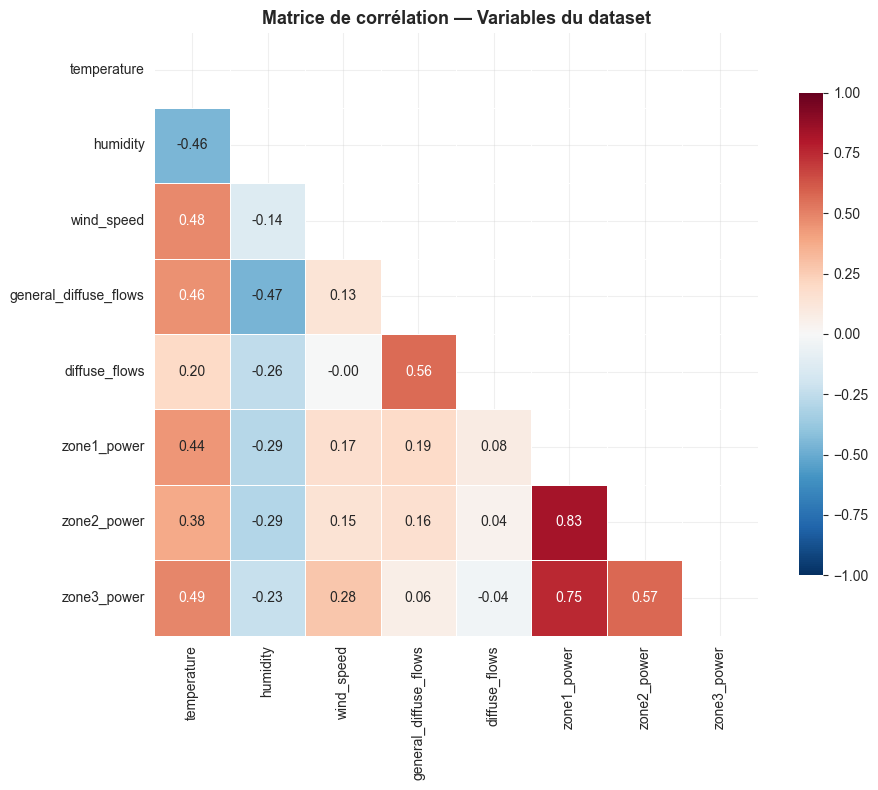

📊 Figure sauvegardée : results/figures/01_matrice_correlation.png


In [17]:
corr_cols = ["temperature", "humidity", "wind_speed", 
             "general_diffuse_flows", "diffuse_flows",
             "zone1_power", "zone2_power", "zone3_power"]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Matrice de corrélation — Variables du dataset", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "figures" / "01_matrice_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Figure sauvegardée : results/figures/01_matrice_correlation.png")

## 11. Comptage des outliers par méthode IQR

Comptage des valeurs au-delà de 1.5 × IQR pour chaque variable. Cela permet de quantifier ce que les boxplots montrent visuellement.

In [18]:
def count_iqr_outliers(series, multiplier=1.5):
    """Compte les outliers par la méthode IQR."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper

outlier_report = []
for col in plot_cols:
    count, lower, upper = count_iqr_outliers(df[col])
    outlier_report.append({
        "Variable": col,
        "Nb outliers (IQR×1.5)": count,
        "Taux (%)": round(count / len(df) * 100, 2),
        "Borne inf": round(lower, 2),
        "Borne sup": round(upper, 2),
    })

outlier_df = pd.DataFrame(outlier_report)
display(outlier_df.style.set_caption("Détection d'outliers — Méthode IQR (×1.5)").hide(axis='index'))

Variable,Nb outliers (IQR×1.5),Taux (%),Borne inf,Borne sup
temperature,142,0.270000,1.690000,35.610000
humidity,291,0.560000,23.670000,116.040000
wind_speed,0,0.000000,-7.180000,12.170000
general_diffuse_flows,2315,4.420000,-479.240000,798.910000
diffuse_flows,4571,8.720000,-151.200000,252.320000
zone1_power,0,0.000000,9813.140000,53806.540000
zone2_power,7,0.010000,5381.340000,36313.140000
zone3_power,1191,2.270000,387.170000,34366.260000


### Interprétation

- Les variables de **flux diffus** présentent de nombreux « outliers » selon l'IQR car leur distribution est très asymétrique (valeurs nocturnes = 0, pics diurnes élevés). Ce ne sont **pas** des anomalies mais des valeurs normales de rayonnement solaire.
- Les **zones de consommation** peuvent avoir des pics liés à des événements réels (canicule, jours fériés). Ces pics doivent être **conservés** pour la modélisation.
- Le traitement des outliers sera approfondi dans le notebook **03 — Prétraitement**.

## 12. Résumé et conclusions de l'audit

### ✅ Points positifs

| Critère | Résultat |
|---|---|
| Valeurs manquantes | **0** — dataset complet |
| Doublons temporels | **0** — index unique |
| Fréquence temporelle | **10 min** — régulière, aucun gap |
| Types de données | Tous `float64` (numériques) |
| Couverture temporelle | 1 an complet (2017-01-01 → 2017-12-30) |
| Volume | 52 416 observations — suffisant pour ML/DL |

### 📝 Points d'attention pour la suite

- **Wind speed et flux diffus** : distributions très asymétriques → pas de normalité.
- **Zone 3** : variance plus élevée que les zones 1 et 2.
- Les outliers identifiés par IQR ne sont **pas** des erreurs mais des phénomènes physiques (rayonnement, pics de consommation).
- Le rééchantillonnage horaire sera nécessaire pour SARIMA et Prophet.

### 🔜 Prochaine étape

Le notebook **02 — EDA** approfondira l'analyse avec des visualisations détaillées : heatmaps heure×jour, décomposition STL, ACF/PACF, relations météo-consommation.

## 13. Sauvegarde du dataset audité

In [19]:
# Sauvegarde du dataset audité pour les notebooks suivants
output_path = PROJECT_ROOT / "data" / "processed" / "tetouan_audited_10min.csv"
df.to_csv(output_path)

print(f"✅ Dataset audité sauvegardé : {output_path}")
print(f"   Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"   Taille fichier : {output_path.stat().st_size / 1024 / 1024:.1f} Mo")

✅ Dataset audité sauvegardé : C:\Users\jarro\OneDrive\Desktop\smart-city-energy-forecasting-tetouan\data\processed\tetouan_audited_10min.csv
   Dimensions : 52,416 lignes × 10 colonnes
   Taille fichier : 5.6 Mo
